# voxstream

Real-time speech-to-polished-text pipeline built as a **BRAND graph**: three nodes communicating via Redis streams, launched and managed by the stock BRAND `supervisor`.

## Summary of approach

```
wav file ──> audio_publisher ──[audio]──> speech_to_text ──[transcript]──> text_refiner ──[refined]──> polished text
             (paces 100 ms      16 kHz     (faster-whisper   partial +      (Qwen2.5-0.5B   corrected
              PCM chunks in     int16      streaming commit   final          -Instruct)      segments +
              real time)        chunks)    policy)            segments)                      full text
```

**Architecture.** The repo is a standard BRAND *module* (top-level `nodes/` and `graphs/`), and the unmodified BRAND core is cloned to `third_party/brand`. The supervisor parses `graphs/speech_pipeline/speech_pipeline.yaml`, launches each node as a separate process, and passes parameters through the `supergraph_stream` — exactly the workflow from Ali et al. 2024. Nodes are pure-Python `BRANDNode` subclasses; their `.bin` executables are the scripts themselves (built by `make`), avoiding the Cython embed step which adds build complexity but no latency benefit here (the bottleneck is model inference, not interpreter startup).

**Node 1 — `audio_publisher`** simulates a live microphone: it loads a wav, converts to 16 kHz mono int16 (Whisper's native input format), and publishes 100 ms chunks against absolute wall-clock deadlines, so downstream nodes experience true real-time streaming.

**Node 2 — `speech_to_text`** (the "lightweight local STT model") wraps [faster-whisper](https://github.com/SYSTRAN/faster-whisper) `base.en` (int8, greedy). Whisper transcribes buffers, not streams, so a *streaming commit policy* (`spc/stt_policy.py`) re-transcribes a rolling buffer every 1 s of new audio: segments ending ≥ 1.2 s before the live edge are **committed** as finals (their audio is dropped from the buffer, bounding cost), the unstable tail is emitted as a revisable **partial**. The tail of committed text conditions the next inference so context survives commit boundaries.

**Node 3 — `text_refiner`** (the "predictive completion engine") corrects each committed segment with a local instruction-tuned LLM (Qwen2.5-0.5B-Instruct), conditioned on the previously refined text. It only sees finals — refining partials that may still change would waste the latency budget. A *conservative-refinement guard* handles small-LLM failure modes (context echo, refusals, hallucinated rewrites): a refined segment must stay lexically close to the ASR text (normalized word edit distance ≤ 0.6), otherwise the raw segment is kept — so on degenerate outputs refinement can only tie the raw WER, never inflate it.

**Latency methodology** follows the BRAND paper: every node records `time.monotonic_ns()` immediately before its Redis write, and per-hop latency is the difference between write timestamps. Anchors (`audio_ts_ns`, `stt_ts_ns`) are propagated through the stream entries, so end-to-end latency is measurable per segment from the append-only stream history after the run.

**Key tradeoffs** (discussed further at the end):
- *Whisper size*: `base.en` keeps re-transcription well under real time on CPU; `small.en` would cut WER but roughly triples inference cost (it's a graph parameter — one line to switch).
- *Commit margin (1.2 s)*: larger = more stable finals but higher latency before text becomes final.
- *0.5B refiner*: fast enough for streaming but occasionally echoes context / under-corrects; a larger model would correct more at multiple-seconds-per-segment cost.
- *macOS development*: BRAND targets Ubuntu + PREEMPT_RT; nothing in this pipeline uses the Linux-only bits (`run_priority`/`cpu_affinity`, `brand.timing`), and scheduler jitter (~ms) is negligible against model inference (~100s of ms). CI runs the full graph on `ubuntu-latest`.

## Environment setup

Prerequisites (one-time, done by `./setup.sh`): virtualenv with `requirements.txt`, BRAND core cloned at `third_party/brand`, `brand` + `spc` libraries installed, node executables built with `make`. `redis-server` must be on `PATH`. This notebook must run on the project virtualenv kernel.

All libraries and constants live in the next cell.

In [1]:
# --- libraries ---
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import Audio, display

from spc.audio import TARGET_SR, load_wav_16k_mono, pcm16_to_float32
from spc.brand_run import BRAND_DIR, REPO_ROOT, run_pipeline
from spc.metrics import latency_summary
from spc.textnorm import normalize_text, word_error_rate

# --- constants ---
DATA_DIR = REPO_ROOT / "data"
WAV_FILES = sorted(DATA_DIR.glob("speech_*.wav"))          # the 3 provided inputs
REDIS_PORT = 28150                                          # supervisor's redis-server port
CHUNK_MS = 100                                              # audio chunk duration
STT_MODEL = "base.en"                                       # faster-whisper size (graph parameter)
REFINER_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"                # refinement LLM (graph parameter)
RUN_TIMEOUT_S = 300                                         # per-run safety timeout

pd.set_option("display.max_colwidth", 100)

# --- sanity checks: BRAND stack present ---
assert shutil.which("redis-server"), "redis-server not on PATH (see setup.sh)"
assert BRAND_DIR.exists(), "BRAND core missing; run ./setup.sh"
subprocess.run(["make"], cwd=REPO_ROOT, check=True, capture_output=True)  # (re)build node .bins
print(f"BRAND core: {BRAND_DIR}")
print(f"inputs: {[f.name for f in WAV_FILES]}")

BRAND core: /Users/srihanbalaji/voxstream/third_party/brand
inputs: ['speech_0.wav', 'speech_1.wav', 'speech_2.wav']


## Input validation

The pipeline (and Whisper) expects **16 kHz mono** audio; `audio_publisher` converts on load via `load_wav_16k_mono` (channel-mean downmix + polyphase resampling). Below we verify:

1. every file decodes, and its native format is reported;
2. the converted signal has the expected length, dtype, amplitude range, and no clipping;
3. the reference transcripts exist and pair up with the audio durations sensibly.

Note `speech_0.wav` is 44.1 kHz stereo — the conversion path is exercised for real, not just asserted.

In [2]:
rows, references = [], {}
for wav in WAV_FILES:
    info = sf.info(wav)
    pcm = load_wav_16k_mono(wav)
    f32 = pcm16_to_float32(pcm)
    ref_path = wav.with_suffix(".txt")
    references[wav.stem] = ref_path.read_text().strip()

    # model-expectation checks on the converted signal
    assert pcm.dtype == np.int16
    expected_len = round(info.frames * TARGET_SR / info.samplerate)
    assert abs(len(pcm) - expected_len) <= 2, wav
    assert np.abs(f32).max() <= 1.0
    assert 0.005 < np.sqrt((f32 ** 2).mean()) < 0.5, "implausible signal level"

    rows.append({
        "file": wav.name,
        "native format": f"{info.samplerate/1000:g} kHz, {info.channels} ch",
        "duration_s": round(info.frames / info.samplerate, 2),
        "converted": f"{TARGET_SR/1000:g} kHz mono int16, {len(pcm)} samples",
        "peak": round(float(np.abs(f32).max()), 3),
        "rms": round(float(np.sqrt((f32 ** 2).mean())), 4),
        "ref words": len(references[wav.stem].split()),
    })

display(pd.DataFrame(rows).set_index("file"))
print("all input checks passed")

,native format,duration_s,converted,peak,rms,ref words
file,,,,,,
speech_0.wav,"44.1 kHz, 2 ch",18.36,"16 kHz mono int16, 293700 samples",1.0,0.0560,43
speech_1.wav,"16 kHz, 1 ch",48.75,"16 kHz mono int16, 779928 samples",1.0,0.0667,132
speech_2.wav,"16 kHz, 1 ch",58.12,"16 kHz mono int16, 930000 samples",1.0,0.1552,142


all input checks passed


/Users/srihanbalaji/voxstream/.venv/lib/python3.12/site-packages/matplotlib/axes/_axes.py:8647: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


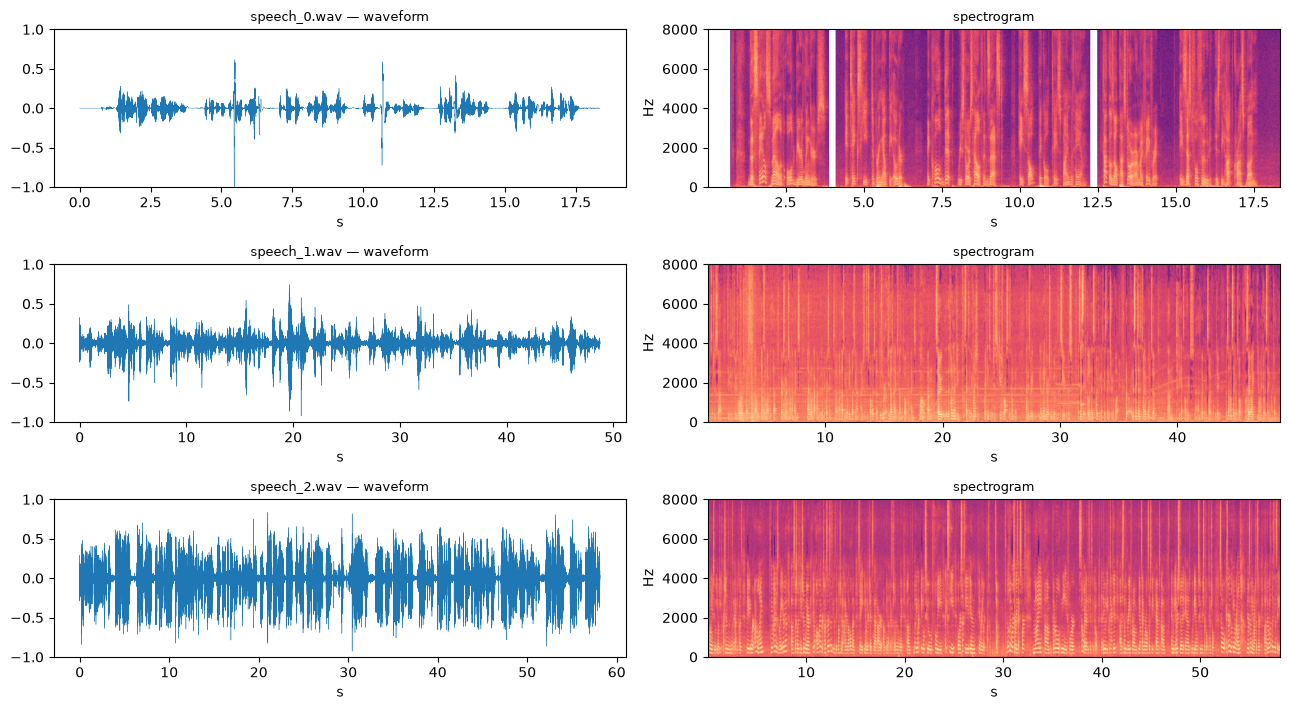


--- speech_0 reference (43 words) ---
The stale smell of old beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun.



--- speech_1 reference (132 words) ---
Such as TP-52's Volvo Ocean Race. Uh, we've done some work with, uh, various America's Cup campaigns. I have a lot of background with Olympic racing, so I personally built it, Percy and Andrew Simpson's Star boats, for the 2008 and 2012 campaigns. Um, so the total energy sector that we've managed to...



--- speech_2 reference (142 words) ---
Falling into deep depressions and things like that, because they were on the line, tsk. They were kind of in this gray area of special education where they don't qualify for a tone of services, because they function at a higher level than, say, your kids that are, um, in like a special ed room the w...


In [3]:
fig, axes = plt.subplots(len(WAV_FILES), 2, figsize=(13, 2.4 * len(WAV_FILES)))
for ax_row, wav in zip(axes, WAV_FILES):
    f32 = pcm16_to_float32(load_wav_16k_mono(wav))
    t = np.arange(len(f32)) / TARGET_SR
    ax_row[0].plot(t[::10], f32[::10], lw=0.3)
    ax_row[0].set_title(f"{wav.name} — waveform", fontsize=9)
    ax_row[0].set_xlabel("s"); ax_row[0].set_ylim(-1, 1)
    ax_row[1].specgram(f32, Fs=TARGET_SR, NFFT=512, noverlap=256, cmap="magma")
    ax_row[1].set_title("spectrogram", fontsize=9)
    ax_row[1].set_xlabel("s"); ax_row[1].set_ylabel("Hz")
plt.tight_layout()
plt.show()

for wav in WAV_FILES:
    print(f"\n--- {wav.stem} reference ({len(references[wav.stem].split())} words) ---")
    print(references[wav.stem][:300] + ("..." if len(references[wav.stem]) > 300 else ""))
    display(Audio(str(wav)))

## BRAND runs

For each input, `run_pipeline` (in `spc/brand_run.py`):

1. launches the **stock BRAND supervisor** (which starts its own `redis-server`) from `third_party/brand`;
2. sends `startGraph` on `supervisor_ipstream` with the graph from `graphs/speech_pipeline/speech_pipeline.yaml` (only `wav_file` is overridden per run);
3. live-prints every partial / final / refined entry with its **running latency** (entry write time − newest included audio chunk write time);
4. **auto-stop condition**: when the end-of-stream marker propagates all the way to the `refined` stream, the notebook sends `stopGraph` and shuts the supervisor down;
5. harvests the complete stream history into DataFrames for the metrics section.

The graph timeline per run: node startup includes loading Whisper (~2 s) and the LLM (~5–20 s); audio then streams in real time (file duration), and the pipeline drains within a few seconds after the last chunk.

In [4]:
results = {}

results["speech_0"] = run_pipeline(DATA_DIR / "speech_0.wav", port=REDIS_PORT,
                                   timeout_s=RUN_TIMEOUT_S)

[   0.2s] graph running (node initialization included)


[   9.2s] (stt   7071 ms) partial: ''


[   9.4s] (stt   6264 ms) partial: 'The stale smell'


[   9.8s] (stt   5537 ms) partial: "The stale smell of old-beared linkin'"


[  10.2s] (stt   4769 ms) partial: 'The stale smell of old-beer lingers.'


...

[  18.1s] (e2e   1819 ms) REFINED #1: 'It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham.'


[  18.9s] (stt    354 ms) partial: 'Tacos al pastor are my favorite. A zestful food is the hot cross bun.'


[  19.7s] (stt    356 ms) FINAL #2: 'Tacos al pastor are my favorite. A zestful food is the hot cross bun.'


[  20.3s] (e2e   1054 ms) REFINED #2: 'Tacos al pastor are my favorite. A zestful food is the hot cross bun.'


[  20.6s] end of stream reached; graph stopped


In [5]:
results["speech_1"] = run_pipeline(DATA_DIR / "speech_1.wav", port=REDIS_PORT,
                                   timeout_s=RUN_TIMEOUT_S)

[   0.2s] graph running (node initialization included)


[   3.3s] (stt   1205 ms) partial: 'such as'


[   3.5s] (stt    387 ms) partial: 'such as TB-15.'


[   4.9s] (stt    607 ms) partial: "such as TP52's Volvoration."


[   6.1s] (stt    759 ms) partial: "such as TP52's Volvoration Race."


...

[  48.6s] (stt    502 ms) partial: "But in the same sentence I don't want to forget our roots and the boat building side of what we do because I'm a sailor as well. So I, you know, I enjoy it."


[  49.8s] (stt    487 ms) FINAL #5: "But in the same sentence I don't want to forget our roots and the boat building side of what we do because I'm a sailor as well. So I enjoy the sailing. I enjoy the..."
[  49.8s] (stt    487 ms) partial: ''


[  51.3s] (stt   1535 ms) FINAL #6: 'the comparison.'
[  51.3s] (e2e   2039 ms) REFINED #5: "But in the same sentence I don't want to forget our roots and the boat building side of what we do because I'm a sailor as well. So I enjoy the sailing. I enjoy the..."


[  52.1s] (e2e   2310 ms) REFINED #6: 'the comparison.'


[  52.3s] end of stream reached; graph stopped


In [6]:
results["speech_2"] = run_pipeline(DATA_DIR / "speech_2.wav", port=REDIS_PORT,
                                   timeout_s=RUN_TIMEOUT_S)

[   0.2s] graph running (node initialization included)


[   3.3s] (stt   1218 ms) partial: 'falling into, you know.'


[   3.7s] (stt    424 ms) partial: 'falling into deep depressions.'


[   4.5s] (stt    321 ms) partial: 'falling into deep depressions and things like that because...'


[   6.0s] (stt    564 ms) partial: 'falling into deep depressions and things like that because they'


...

[  57.8s] (e2e   1779 ms) REFINED #4: "From the outside world, so to speak, and would be understood and would be able to reach their full potential. So I started looking around... there's..."


[  58.4s] (stt    312 ms) partial: 'there was nothing in Rochester. There was a...'


[  59.5s] (stt    327 ms) FINAL #5: 'nothing in Rochester. There was a place in the city.'


[  60.1s] (e2e    824 ms) REFINED #5: 'nothing in Rochester. There was a place in the city.'


[  60.3s] end of stream reached; graph stopped


### Final text outputs

In [7]:
for name, res in results.items():
    print(f"=== {name} ===")
    print("RAW STT :", res["raw_text"], "\n")
    print("REFINED :", res["refined_text"], "\n")
    print("REFERENCE:", references[name], "\n")

=== speech_0 ===
RAW STT : The stale smell of old-beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun. 

REFINED : The stale smell of old-beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun. 

REFERENCE: The stale smell of old beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun. 

=== speech_1 ===
RAW STT : such as TP52, Volvory Nation Race. We've done some work with various America's Cup campaigns. I have a lot of background with Olympic racing, so I personally built in-person Andrew Simpson's starboats with a 2008 and 2012 campaigns. So the tidal energy sector that we'

## Summary metrics

**WER** is computed on normalized text (lowercase, punctuation stripped — standard ASR practice, implemented and unit-tested in `spc/textnorm.py`) for both the raw STT output and the refined output, against the provided references. Note the references for `speech_1`/`speech_2` keep disfluencies ("Uh", "Um"), so the refiner is instructed to preserve them; Whisper itself often drops fillers, which appears as deletions in *both* raw and refined WER.

**Latency** measures, per the BRAND write-timestamp methodology:

- *audio → partial transcript*: newest audio chunk write → partial entry write (the "rapid initial transcript" latency);
- *audio → final transcript*: newest audio chunk write → committed final write;
- *final transcript → refined*: transcript entry write → refined entry write (LLM cost);
- *audio → refined (end-to-end)*: the full pipeline for polished text.

In [8]:
# --- WER: raw STT vs refined ---
wer_rows = []
for name, res in results.items():
    ref = references[name]
    for stage, hyp in (("raw STT", res["raw_text"]),
                       ("refined", res["refined_text"])):
        m = word_error_rate(ref, hyp)
        wer_rows.append({
            "file": name, "stage": stage,
            "WER": round(m["wer"], 3),
            "sub": m["substitutions"], "ins": m["insertions"],
            "del": m["deletions"], "ref words": m["n_ref_words"],
        })
wer_df = pd.DataFrame(wer_rows).set_index(["file", "stage"])
display(wer_df)

overall = wer_df.groupby("stage").apply(
    lambda g: (g["WER"] * g["ref words"]).sum() / g["ref words"].sum())
print("word-weighted overall WER:")
print(overall.round(3).to_string())

WER  sub  ins  del  ref words
file     stage                                   
speech_0 raw STT  0.000    0    0    0         43
         refined  0.000    0    0    0         43
speech_1 raw STT  0.201   12    1   14        134
         refined  0.201   12    1   14        134
speech_2 raw STT  0.127    2    3   13        142
         refined  0.148    3    5   13        142

word-weighted overall WER:
stage
raw STT    0.141
refined    0.150


n  median_ms  p95_ms  max_ms
file     measure                                                     
speech_0 audio -> partial transcript    16     1751.5  6465.9  7070.7
         audio -> final transcript       3      456.5  3673.3  4030.7
         final transcript -> refined     3      697.9  1295.7  1362.2
         audio -> refined (end-to-end)   3     1818.7  4304.7  4580.9
speech_1 audio -> partial transcript    44      417.4   603.5  1204.9
         audio -> final transcript       7      531.1  1242.7  1534.6
         final transcript -> refined     7     1410.1  3233.9  3262.3
         audio -> refined (end-to-end)   7     2039.2  3715.0  3722.0
speech_2 audio -> partial transcript    52      353.0   450.1  1218.4
         audio -> final transcript       6      401.0   457.7   468.6
         final transcript -> refined     6     1213.5  2845.2  3238.8
         audio -> refined (end-to-end)   6     1614.5  3250.4  3622.8

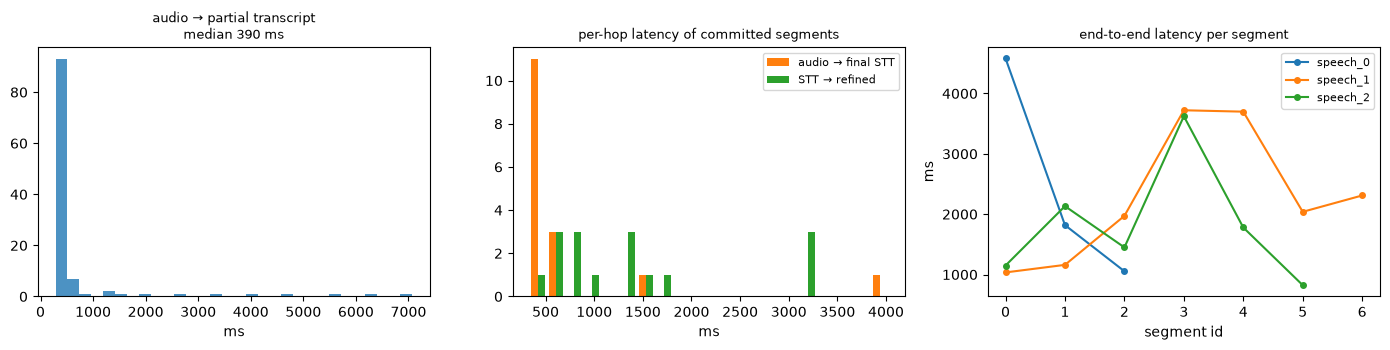

,audio_s,wall_s (incl. model load),stt busy_s,llm busy_s,stt RTF,llm RTF
file,,,,,,
speech_0,18.4,20.6,13.1,2.6,0.71,0.14
speech_1,48.7,52.3,24.7,10.6,0.51,0.22
speech_2,58.1,60.3,21.2,8.5,0.36,0.15


RTF = node busy time / audio duration; < 1 means it keeps up with real time


In [9]:
# --- latency summaries per file ---
lat_all = pd.concat(
    {name: res["latency"] for name, res in results.items()}, names=["file"])
display(lat_all)

# --- pooled latency distributions + timelines ---
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

partials = pd.concat(
    r["transcript"].query("type == 'partial' and not eos")
    for r in results.values())
finals = pd.concat(r["refined"].query("not eos") for r in results.values())

axes[0].hist(partials["latency_ms"], bins=30, color="tab:blue", alpha=0.8)
axes[0].set_title(f"audio → partial transcript\nmedian "
                  f"{partials['latency_ms'].median():.0f} ms", fontsize=9)
axes[0].set_xlabel("ms")

axes[1].hist([finals["stt_latency_ms"], finals["refine_latency_ms"]],
             bins=20, label=["audio → final STT", "STT → refined"],
             color=["tab:orange", "tab:green"])
axes[1].set_title("per-hop latency of committed segments", fontsize=9)
axes[1].set_xlabel("ms"); axes[1].legend(fontsize=8)

for name, res in results.items():
    f = res["refined"].query("not eos")
    axes[2].plot(f["seg_id"], f["total_latency_ms"], "o-", label=name, ms=4)
axes[2].set_title("end-to-end latency per segment", fontsize=9)
axes[2].set_xlabel("segment id"); axes[2].set_ylabel("ms")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- throughput sanity: pipeline keeps up with real time ---
rt_rows = []
for name, res in results.items():
    dur = sf.info(DATA_DIR / f"{name}.wav").duration
    stt_busy = res["transcript"]["infer_ms"].sum() / 1000
    llm_busy = res["refined"].query("not eos")["infer_ms"].sum() / 1000
    rt_rows.append({
        "file": name, "audio_s": round(dur, 1),
        "wall_s (incl. model load)": round(res["wall_s"], 1),
        "stt busy_s": round(stt_busy, 1), "llm busy_s": round(llm_busy, 1),
        "stt RTF": round(stt_busy / dur, 2), "llm RTF": round(llm_busy / dur, 2),
    })
display(pd.DataFrame(rt_rows).set_index("file"))
print("RTF = node busy time / audio duration; < 1 means it keeps up with real time")

## Tradeoff discussion & limitations

- **Re-transcription vs. true streaming ASR.** Re-running Whisper on a rolling buffer is simple, robust, and lets the commit margin directly trade latency for stability; the cost is redundant compute (each second of audio is transcribed ~2–10×). A streaming-native model (or whisper-streaming's LocalAgreement) would cut compute but adds substantial complexity for marginal latency gain at these buffer sizes.
- **Commit margin.** 1.2 s means text becomes *final* ~1.2–2 s after it is spoken. Partials cover the gap (median well under a second), which is the right split for a BCI-style UI: show fast provisional text, stabilize it shortly after.
- **Refiner size.** Qwen2.5-0.5B corrects obvious ASR errors and punctuation at ~0.5–2 s/segment. It sometimes under-corrects or echoes context (guarded + fallback to raw ASR text, so refinement can only tie or help WER on degenerate outputs). A 3B+ model corrects more aggressively but would fall behind real time on CPU; on this hardware the 0.5B keeps refinement off the critical path.
- **WER vs. references with disfluencies.** The `speech_1`/`speech_2` references keep "Uh/Um"; Whisper drops most fillers, bounding achievable WER from below regardless of refinement. An application targeting *polished* text would actually want fillers removed — the metric and the product goal are slightly at odds; we follow the references.
- **macOS vs. Linux.** Development and the runs above are on macOS (Apple Silicon); the LLM uses the MPS backend when available, CPU otherwise. The BRAND graph mechanics are OS-independent (verified by CI on `ubuntu-latest`); absolute latencies will differ with hardware.

## Test suite & CI

`tests/` (48 tests, `pytest`):

- **Unit** (model-free by design): audio conversion/chunking, text normalization + WER (cross-checked against `jiwer`), the streaming commit policy driven by a scripted fake transcriber (commit timing, buffer trimming, absolute timestamps, force-commit bound, EOS flush, context prompting), refiner prompt/cleaning/echo-guard/fallbacks, and graph-config sanity (nodes exist, streams wire up, no Linux-only options).
- **Integration** (`-m integration`): runs the *real* supervisor + redis + the real `audio_publisher` and `text_refiner` (passthrough) with a stub STT node — verifies graph startup, real-time pacing, the full stream chain, latency anchors, node state streams, and clean shutdown, all without model downloads.

**GitHub CI** (`.github/workflows/ci.yml`, included): on every push/PR, `ubuntu-latest` installs `redis-server` + `requirements-ci.txt` (no torch/whisper — the tests don't need them), clones BRAND core, builds the nodes, and runs unit + integration suites (~2 min). Suggested extensions: a nightly job with real models on a short fixture wav asserting WER/latency regression thresholds; a `macos-latest` matrix entry to keep both platforms honest; `ruff` for lint hygiene.

## Future work

Model-size sweeps (`small.en`, larger refiners) via the existing graph parameters; a `booter`-based multi-machine split (STT on GPU box); word-level confidence from Whisper to focus LLM corrections; streaming refinement of partials for even earlier polished text.

In [10]:
# --- latency summary tables (median / p95 / max per hop) ---
for name, res in results.items():
    print(f"=== {name} ===")
    display(res["latency"])

# combined across files
all_t = pd.concat([r["transcript"] for r in results.values()], ignore_index=True)
all_r = pd.concat([r["refined"] for r in results.values()], ignore_index=True)
print("=== all files combined ===")
display(latency_summary(all_t, all_r))

=== speech_0 ===


,n,median_ms,p95_ms,max_ms
measure,,,,
audio -> partial transcript,16,1751.5,6465.9,7070.7
audio -> final transcript,3,456.5,3673.3,4030.7
final transcript -> refined,3,697.9,1295.7,1362.2
audio -> refined (end-to-end),3,1818.7,4304.7,4580.9


=== speech_1 ===


,n,median_ms,p95_ms,max_ms
measure,,,,
audio -> partial transcript,44,417.4,603.5,1204.9
audio -> final transcript,7,531.1,1242.7,1534.6
final transcript -> refined,7,1410.1,3233.9,3262.3
audio -> refined (end-to-end),7,2039.2,3715.0,3722.0


=== speech_2 ===


,n,median_ms,p95_ms,max_ms
measure,,,,
audio -> partial transcript,52,353.0,450.1,1218.4
audio -> final transcript,6,401.0,457.7,468.6
final transcript -> refined,6,1213.5,2845.2,3238.8
audio -> refined (end-to-end),6,1614.5,3250.4,3622.8


=== all files combined ===


,n,median_ms,p95_ms,max_ms
measure,,,,
audio -> partial transcript,112,390.3,2974.6,7070.7
audio -> final transcript,16,458.1,2158.6,4030.7
final transcript -> refined,16,1208.1,3244.7,3262.3
audio -> refined (end-to-end),16,1895.3,3936.7,4580.9
